# Supplementary Figure: Feature Category Enrichment

This notebook recreates the figure "Feature Category Enrichment Analysis\nFrequency Distribution with Enrichment Status" using only the data and computations required for that figure.

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy.stats import hypergeom

FS_TITLE = 12
FS_SUBTITLE = 11
FS_LABEL = 11
FS_TICK = 11
FS_LEGEND = 10
FS_TEXT = 9

plt.style.use('default')
plt.rcParams.update({
    'font.size': FS_TEXT,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

base_dir = Path('/home/tobamo/analize/project-tobamo/analysis/model')
final_model_dir = base_dir / 'results' / 'final_model'
figures_dir = base_dir / 'figures'
figures_dir.mkdir(exist_ok=True)

all_features = pd.read_csv(final_model_dir / 'all_features.csv')
top_40_features = pd.read_csv(final_model_dir / 'top_40_features.csv')
top_40_set = set(top_40_features['Feature'])

print(f'Total features: {len(all_features)}')
print(f'Top features used for enrichment test: {len(top_40_features)}')

Total features: 148
Top features used for enrichment test: 40


In [9]:
def parse_feature_components(feature_name: str) -> dict:
    components = {
        'sequence_type': None,
        'protein': None,
        'metric': None,
        'is_basic': False,
    }

    if feature_name in ['orf_len', 'contig_length', 'stop_codons', 'orf_acc_method']:
        components['is_basic'] = True
        components['metric'] = feature_name
        return components

    if feature_name.startswith('tobamo_'):
        components['sequence_type'] = 'tobamo'
        remaining = feature_name.replace('tobamo_', '')
    elif feature_name.startswith('outgroup_'):
        components['sequence_type'] = 'outgroup'
        remaining = feature_name.replace('outgroup_', '')
    else:
        return components

    for pattern in ['orf1_', 'orf2_', 'cp_']:
        if remaining.startswith(pattern):
            components['protein'] = pattern.rstrip('_')
            remaining = remaining.replace(pattern, '')
            break

    for pattern in ['_min', '_max', '_mean']:
        if remaining.endswith(pattern):
            remaining = remaining.replace(pattern, '')
            break

    components['metric'] = remaining
    return components

def categorize_metric(metric: str) -> str:
    if metric == 'orf_len':
        return 'orf_len'
    if metric == 'contig_length':
        return 'contig_length'
    if metric == 'stop_codons':
        return 'stop_codons'
    if metric == 'orf_acc_method':
        return 'orf_acc_method'
    if 'identity_score' in str(metric):
        return 'identity_score'
    if 'gap_ratio' in str(metric):
        return 'gap_ratio'
    if 'gap_openings' in str(metric):
        return 'gap_openings'
    if 'aln_len' in str(metric) and 'N/aln_len' not in str(metric):
        return 'aln_len'
    if 'aln_orf_len' in str(metric):
        return 'aln_orf_len'
    if 'N/aln_len' in str(metric):
        return 'N_aln_len_ratio'
    if '_M_' in str(metric) or str(metric).endswith('_M'):
        return 'match_count'
    if '_N_' in str(metric) or str(metric).endswith('_N'):
        return 'mismatch_count'
    return 'other'

def create_protein_category(row) -> str:
    if row['is_basic']:
        return row['metric']
    if pd.isna(row['protein']):
        return 'unknown'
    return f"{row['sequence_type']}_{row['protein']}"

def hypergeometric_test(df: pd.DataFrame, category_col: str, category_name: str, total_top: int) -> dict:
    category_features = df[df[category_col] == category_name]
    observed = int(category_features['is_top40'].sum())
    category_total = len(category_features)
    total_features = len(df)

    p_value = 1 - hypergeom.cdf(observed - 1, total_features, category_total, total_top)
    expected = (category_total / total_features) * total_top
    enrichment = observed / expected if expected > 0 else float('inf')

    return {
        'category': category_name,
        'observed': observed,
        'expected': expected,
        'enrichment_factor': enrichment,
        'p_value': p_value,
        'significant': p_value < 0.05,
    }

components = []
for _, row in all_features.iterrows():
    parsed = parse_feature_components(row['Feature'])
    parsed['is_top40'] = row['Feature'] in top_40_set
    components.append(parsed)

components_df = pd.DataFrame(components)
components_df['metric_category'] = components_df['metric'].apply(categorize_metric)
components_df['protein_category'] = components_df.apply(create_protein_category, axis=1)

metric_hyper_df = pd.DataFrame([
    hypergeometric_test(components_df, 'metric_category', cat, len(top_40_features))
    for cat in sorted(components_df['metric_category'].dropna().unique())
]).sort_values('observed', ascending=False).reset_index(drop=True)

protein_hyper_df = pd.DataFrame([
    hypergeometric_test(components_df, 'protein_category', cat, len(top_40_features))
    for cat in sorted(components_df['protein_category'].dropna().unique())
]).sort_values('observed', ascending=False).reset_index(drop=True)

metric_hyper_df = metric_hyper_df[metric_hyper_df['observed'] > 0].reset_index(drop=True)
protein_hyper_df = protein_hyper_df[protein_hyper_df['observed'] > 0].reset_index(drop=True)

print(f'Metric categories in figure: {len(metric_hyper_df)}')
print(f'Protein categories in figure: {len(protein_hyper_df)}')

Metric categories in figure: 7
Protein categories in figure: 8


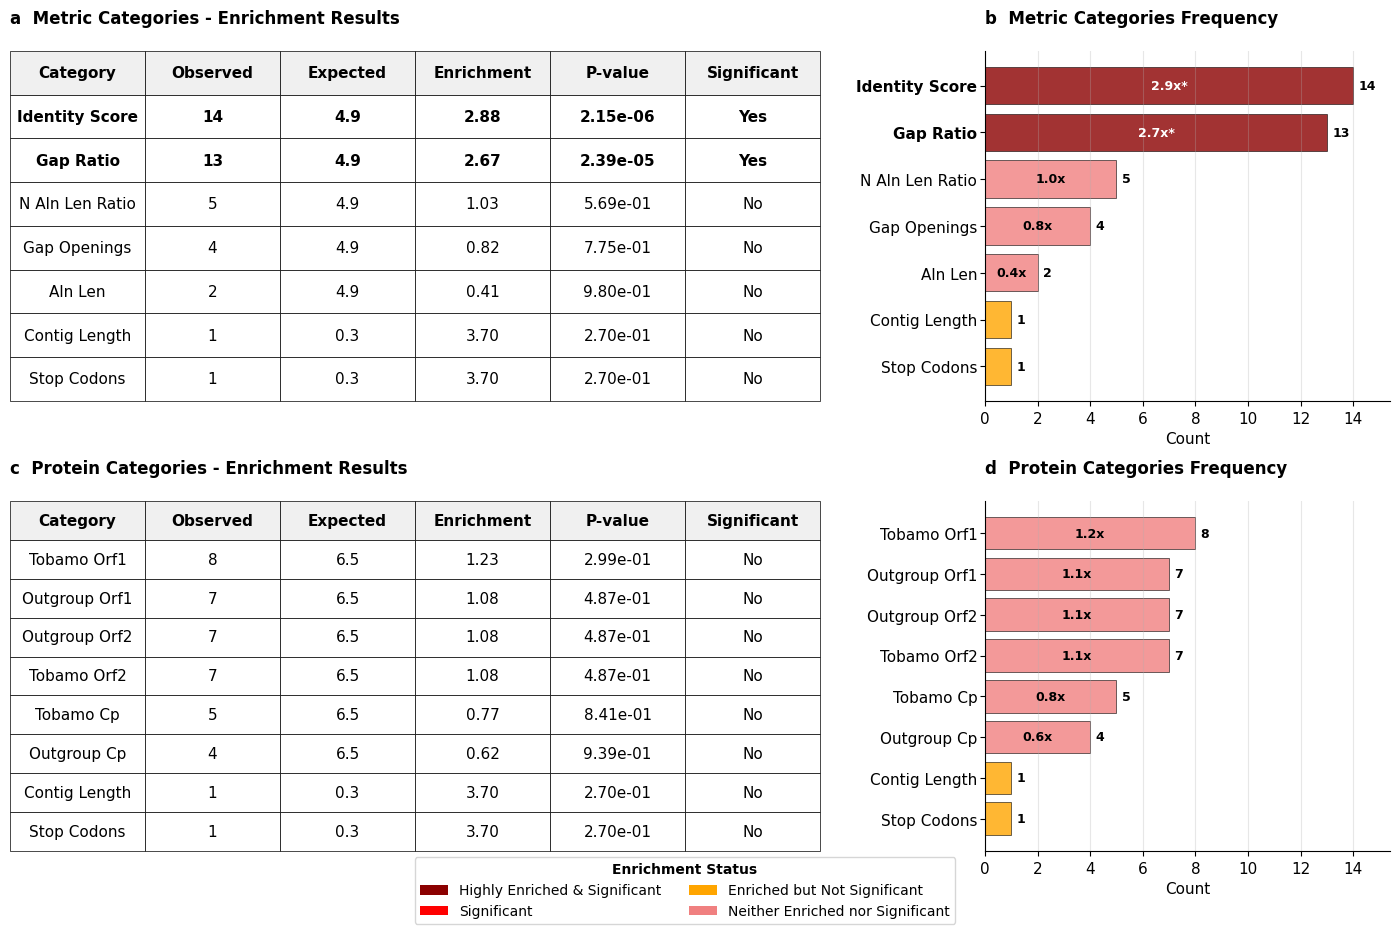

Saved figure to: /home/tobamo/analize/project-tobamo/analysis/model/figures/supp_fig3_feature_enrichment.png


In [13]:
fig, ((ax_metric_table, ax_metric_bars), (ax_protein_table, ax_protein_bars)) = plt.subplots(2, 2, figsize=(15, 10))
fig.subplots_adjust(wspace=0.25, hspace=0.25)

ax_metric_table.set_position([0.05, 0.55, 0.54, 0.35])
ax_metric_bars.set_position([0.70, 0.55, 0.27, 0.35])
ax_protein_table.set_position([0.05, 0.1, 0.54, 0.35])
ax_protein_bars.set_position([0.70, 0.1, 0.27, 0.35])

def build_table(ax, df, panel_label, heading):
    table_data = [[
        row['category'].replace('_', ' ').title(),
        f"{int(row['observed'])}",
        f"{row['expected']:.1f}",
        f"{row['enrichment_factor']:.2f}",
        f"{row['p_value']:.2e}",
        'Yes' if row['significant'] else 'No',
    ] for _, row in df.iterrows()]

    table = ax.table(
        cellText=table_data,
        colLabels=['Category', 'Observed', 'Expected', 'Enrichment', 'P-value', 'Significant'],
        cellLoc='center',
        loc='center',
        bbox=[0, 0, 1, 1],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(FS_LABEL)
    table.scale(1, 2.0)

    for i, (_, row) in enumerate(df.iterrows()):
        if row['significant']:
            for j in range(6):
                table[(i + 1, j)].set_text_props(weight='bold')

    for (i, j), cell in table.get_celld().items():
        if i == 0:
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#f0f0f0')
        cell.set_edgecolor('black')
        cell.set_linewidth(0.5)

    ax.axis('off')
    ax.set_title(f'{panel_label}  {heading}', loc='left', fontweight='bold', fontsize=FS_TITLE, pad=20)

def enrichment_color(significant, enrichment):
    if significant and enrichment > 1.5:
        return 'darkred'
    if significant:
        return 'red'
    if enrichment > 1.5:
        return 'orange'
    return 'lightcoral'

def build_bar(ax, df, panel_label, heading, note_text=None):
    categories = [c.replace('_', ' ').title() for c in df['category']]
    observed = df['observed'].to_list()
    enrichment = df['enrichment_factor'].to_list()
    significant = df['significant'].to_list()
    colors = [enrichment_color(s, e) for s, e in zip(significant, enrichment)]

    y_pos = range(len(categories))
    bars = ax.barh(y_pos[::-1], observed, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

    for bar, obs, enr, sig in zip(bars, observed, enrichment, significant):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                f'{obs}', ha='left', va='center', fontweight='bold', fontsize=FS_TEXT)
        if bar.get_width() > 1:
            marker = '*' if sig else ''
            txt_color = 'white' if enr > 1.5 else 'black'
            ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                    f'{enr:.1f}x{marker}', ha='center', va='center',
                    fontweight='bold', fontsize=FS_TEXT, color=txt_color)

    ax.set_yticks(y_pos[::-1])
    ax.set_yticklabels(categories, fontsize=FS_TICK)
    ax.set_xlabel('Count', fontsize=FS_LABEL)
    ax.set_title(f'{panel_label}  {heading}', loc='left', fontweight='bold', fontsize=FS_TITLE, pad=20)
    ax.tick_params(axis='x', labelsize=FS_TICK)
    ax.tick_params(axis='y', labelsize=FS_TICK, pad=2)
    ax.grid(True, alpha=0.3, axis='x')

    if note_text:
        ax.text(0.0, -0.14, note_text, transform=ax.transAxes, ha='left', va='top', fontsize=FS_TEXT)

    for label, sig in zip(ax.get_yticklabels(), significant):
        if sig:
            label.set_fontweight('bold')

build_table(ax_metric_table, metric_hyper_df, 'a', 'Metric Categories - Enrichment Results')
build_bar(
    ax_metric_bars,
    metric_hyper_df,
    'b',
    'Metric Categories Frequency'
)
build_table(ax_protein_table, protein_hyper_df, 'c', 'Protein Categories - Enrichment Results')
build_bar(
    ax_protein_bars,
    protein_hyper_df,
    'd',
    'Protein Categories Frequency'

)

shared_max = max(metric_hyper_df['observed'].max(), protein_hyper_df['observed'].max())
ax_metric_bars.set_xlim(0, shared_max * 1.1)
ax_protein_bars.set_xlim(0, shared_max * 1.1)

legend_elements = [
    Patch(facecolor='darkred', label='Highly Enriched & Significant'),
    Patch(facecolor='red', label='Significant'),
    Patch(facecolor='orange', label='Enriched but Not Significant'),
    Patch(facecolor='lightcoral', label='Neither Enriched nor Significant'),
]
fig.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.02),
    ncol=2,
    fontsize=FS_LEGEND,
    frameon=True,
    title='Enrichment Status',
    title_fontproperties={'weight': 'bold', 'size': FS_LEGEND},
)

output_path = figures_dir / 'supp_fig3_feature_enrichment.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved figure to: {output_path}')